# Imports

In [1]:
import os
os.chdir('JA_SIREN/')
import numpy as np
from scipy.special import jv
import matplotlib.pyplot as plt
from skimage import data
import numpy as np
from scipy.fft import dst, idst, dct, idct
from scipy.optimize import brentq
from skimage.transform import resize
import torch
import torch.nn as nn
from skimage import data as skdatas
from PIL import Image
from skimage.transform import resize
from skimage.metrics import peak_signal_noise_ratio as psnr
from tqdm import tqdm
from scipy import ndimage
from helpers import *
import json
import librosa
from IPython.display import Audio
from PIL import Image as PILImage

plt.rcParams['font.family'] = 'serif'   # set global font family

# GPU settings:
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Load Image

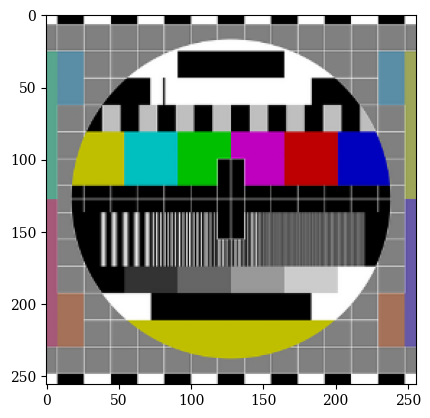

In [4]:
## Load and prepare data
# cameraman:
img = data.camera()
desired_size = 256
img = resize(img, (desired_size, desired_size), preserve_range=True)/255.0

# Television test:
Data_path = 'PCP.png'
img = np.array(Image.open(Data_path)).astype(np.uint8)/255.0
W, H, C = np.shape(img)

v = img.flatten().astype(np.float64)
N = len(v)
V = dst(v, type=2)
magnitudes = np.abs(V)
sorted_idx = np.argsort(magnitudes)[::-1]

## Compute compositional parameters
M = 512 # network width
primary_idx = sorted_idx[:M]
primary_amps = V[primary_idx] / N  # signed
a_comps = np.array([find_a(a) for a in primary_amps])
signs   = np.sign(primary_amps)

n_idx_np = np.linspace(-1, 1, N)
n_idx    = torch.tensor(n_idx_np, dtype=torch.float32).unsqueeze(1)
v_tensor = torch.tensor(v,        dtype=torch.float32).unsqueeze(1)

plt.imshow(img)

# Train Model

Model init PSNR=7.89 dB


Training: 100%|██████████| 1000/1000 [00:28<00:00, 35.19step/s, best_psnr=70.12, lr=9.77e-05, psnr=70.12]


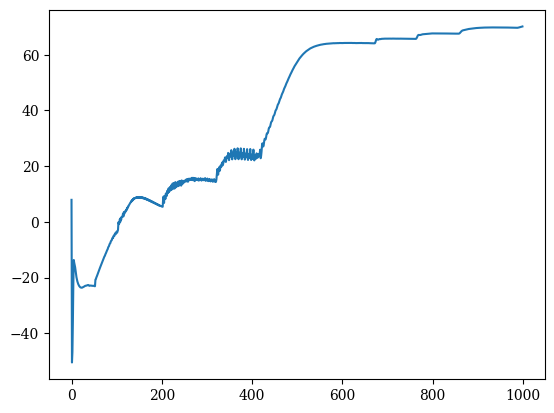

In [6]:
device = torch.device('cuda')
model = JA_SIREN(v,M).to(device)

# Verify initialization
n_idx_gpu  = n_idx.to(device)
v_tensor_gpu = v_tensor.to(device)
with torch.no_grad():
    v_pred = model(n_idx_gpu).squeeze().cpu().detach().numpy()
psnr_init = 10 * np.log10(1.0 / np.mean((v - v_pred)**2))
print(f"Model init PSNR={psnr_init:.2f} dB")

psnr_JA, state, curve = train(model, n_idx_gpu, v_tensor_gpu, steps1=1000, lr=1)

plt.plot(curve)